In [1]:

%%time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

CPU times: total: 5.22 s
Wall time: 6.85 s


In [2]:
df = pd.read_csv("../data/student_placement_sample.csv")
df.head()

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,branch,college_tier,python_skill,c++_skill,...,time_management,gender,city_tier,family_income,placed,programming_skill,technical_skill,academic_score,experience_score,problem_solving_index
0,22,6.92,0,73.671705,67.348211,92.107604,EE,3,5,5,...,9,Male,1,4.522336,1,6.333333,5.6,76.218605,12,46.022886
1,23,8.41,0,76.744599,83.436313,89.369896,CE,3,2,8,...,2,Female,3,8.775525,1,5.000000,5.0,85.635403,9,38.586494
2,21,7.70,1,85.945034,67.848361,73.393314,IT,3,9,4,...,3,Male,1,6.159067,1,5.666667,5.0,72.747225,12,58.874571
3,21,8.29,0,87.053234,69.491324,73.509382,ECE,2,4,7,...,8,Female,2,7.880186,0,4.666667,4.0,75.300235,6,54.172023
4,20,5.37,3,71.777160,72.859973,63.529267,ME,3,6,1,...,9,Female,1,7.711460,0,4.333333,5.0,63.363080,14,37.522803


## EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    20000 non-null  int64  
 1   cgpa                   20000 non-null  float64
 2   backlogs               20000 non-null  int64  
 3   attendance             20000 non-null  float64
 4   tenth_percentage       20000 non-null  float64
 5   twelfth_percentage     20000 non-null  float64
 6   branch                 20000 non-null  str    
 7   college_tier           20000 non-null  int64  
 8   python_skill           20000 non-null  int64  
 9   c++_skill              20000 non-null  int64  
 10  java_skill             20000 non-null  int64  
 11  ml_skill               20000 non-null  int64  
 12  web_dev_skill          20000 non-null  int64  
 13  communication_skill    20000 non-null  int64  
 14  aptitude_score         20000 non-null  float64
 15  logical_reaso

In [4]:
df.placed.value_counts()

placed
1    10038
0     9962
Name: count, dtype: int64

In [5]:
df.isna().sum()

age                      0
cgpa                     0
backlogs                 0
attendance               0
tenth_percentage         0
twelfth_percentage       0
branch                   0
college_tier             0
python_skill             0
c++_skill                0
java_skill               0
ml_skill                 0
web_dev_skill            0
communication_skill      0
aptitude_score           0
logical_reasoning        0
internships              0
projects                 0
github_projects          0
hackathons               0
certifications           0
coding_contest_rating    0
teamwork                 0
leadership               0
problem_solving          0
time_management          0
gender                   0
city_tier                0
family_income            0
placed                   0
programming_skill        0
technical_skill          0
academic_score           0
experience_score         0
problem_solving_index    0
dtype: int64

In [6]:
df.describe()

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,college_tier,python_skill,c++_skill,java_skill,...,problem_solving,time_management,city_tier,family_income,placed,programming_skill,technical_skill,academic_score,experience_score,problem_solving_index
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,...,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,22.497900,7.499085,1.202650,79.929242,77.965209,74.878126,2.005500,4.50890,4.491000,4.493300,...,4.50645,4.496250,1.998850,8.008244,0.501900,4.497733,4.495940,75.944730,9.53025,43.102798
std,1.712467,0.994084,1.106004,9.792943,9.883886,11.775437,0.812713,2.88169,2.865489,2.869315,...,2.86595,2.874352,0.813192,2.984741,0.500009,1.650848,1.276977,6.055629,3.10317,7.091876
min,20.000000,5.000000,0.000000,40.000000,40.000000,40.000000,1.000000,0.00000,0.000000,0.000000,...,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.200000,52.496710,0.00000,15.315324
25%,21.000000,6.820000,0.000000,73.326385,71.347185,66.874507,1.000000,2.00000,2.000000,2.000000,...,2.00000,2.000000,1.000000,5.932038,0.000000,3.333333,3.600000,71.855132,7.00000,38.374298
50%,22.000000,7.500000,1.000000,79.967806,78.017561,74.818776,2.000000,5.00000,4.000000,4.000000,...,5.00000,4.000000,2.000000,7.970676,1.000000,4.333333,4.400000,75.925470,9.00000,43.138158
75%,24.000000,8.170000,2.000000,86.832208,84.761382,83.013011,3.000000,7.00000,7.000000,7.000000,...,7.00000,7.000000,3.000000,10.062760,1.000000,5.666667,5.400000,80.038656,12.00000,47.898178
max,25.000000,10.000000,7.000000,100.000000,100.000000,100.000000,3.000000,9.00000,9.000000,9.000000,...,9.00000,9.000000,3.000000,19.015142,1.000000,9.000000,8.800000,97.056756,23.00000,68.666667


In [7]:
len(df)

20000

In [8]:
%%time
df.shape

CPU times: total: 0 ns
Wall time: 0 ns


(20000, 35)

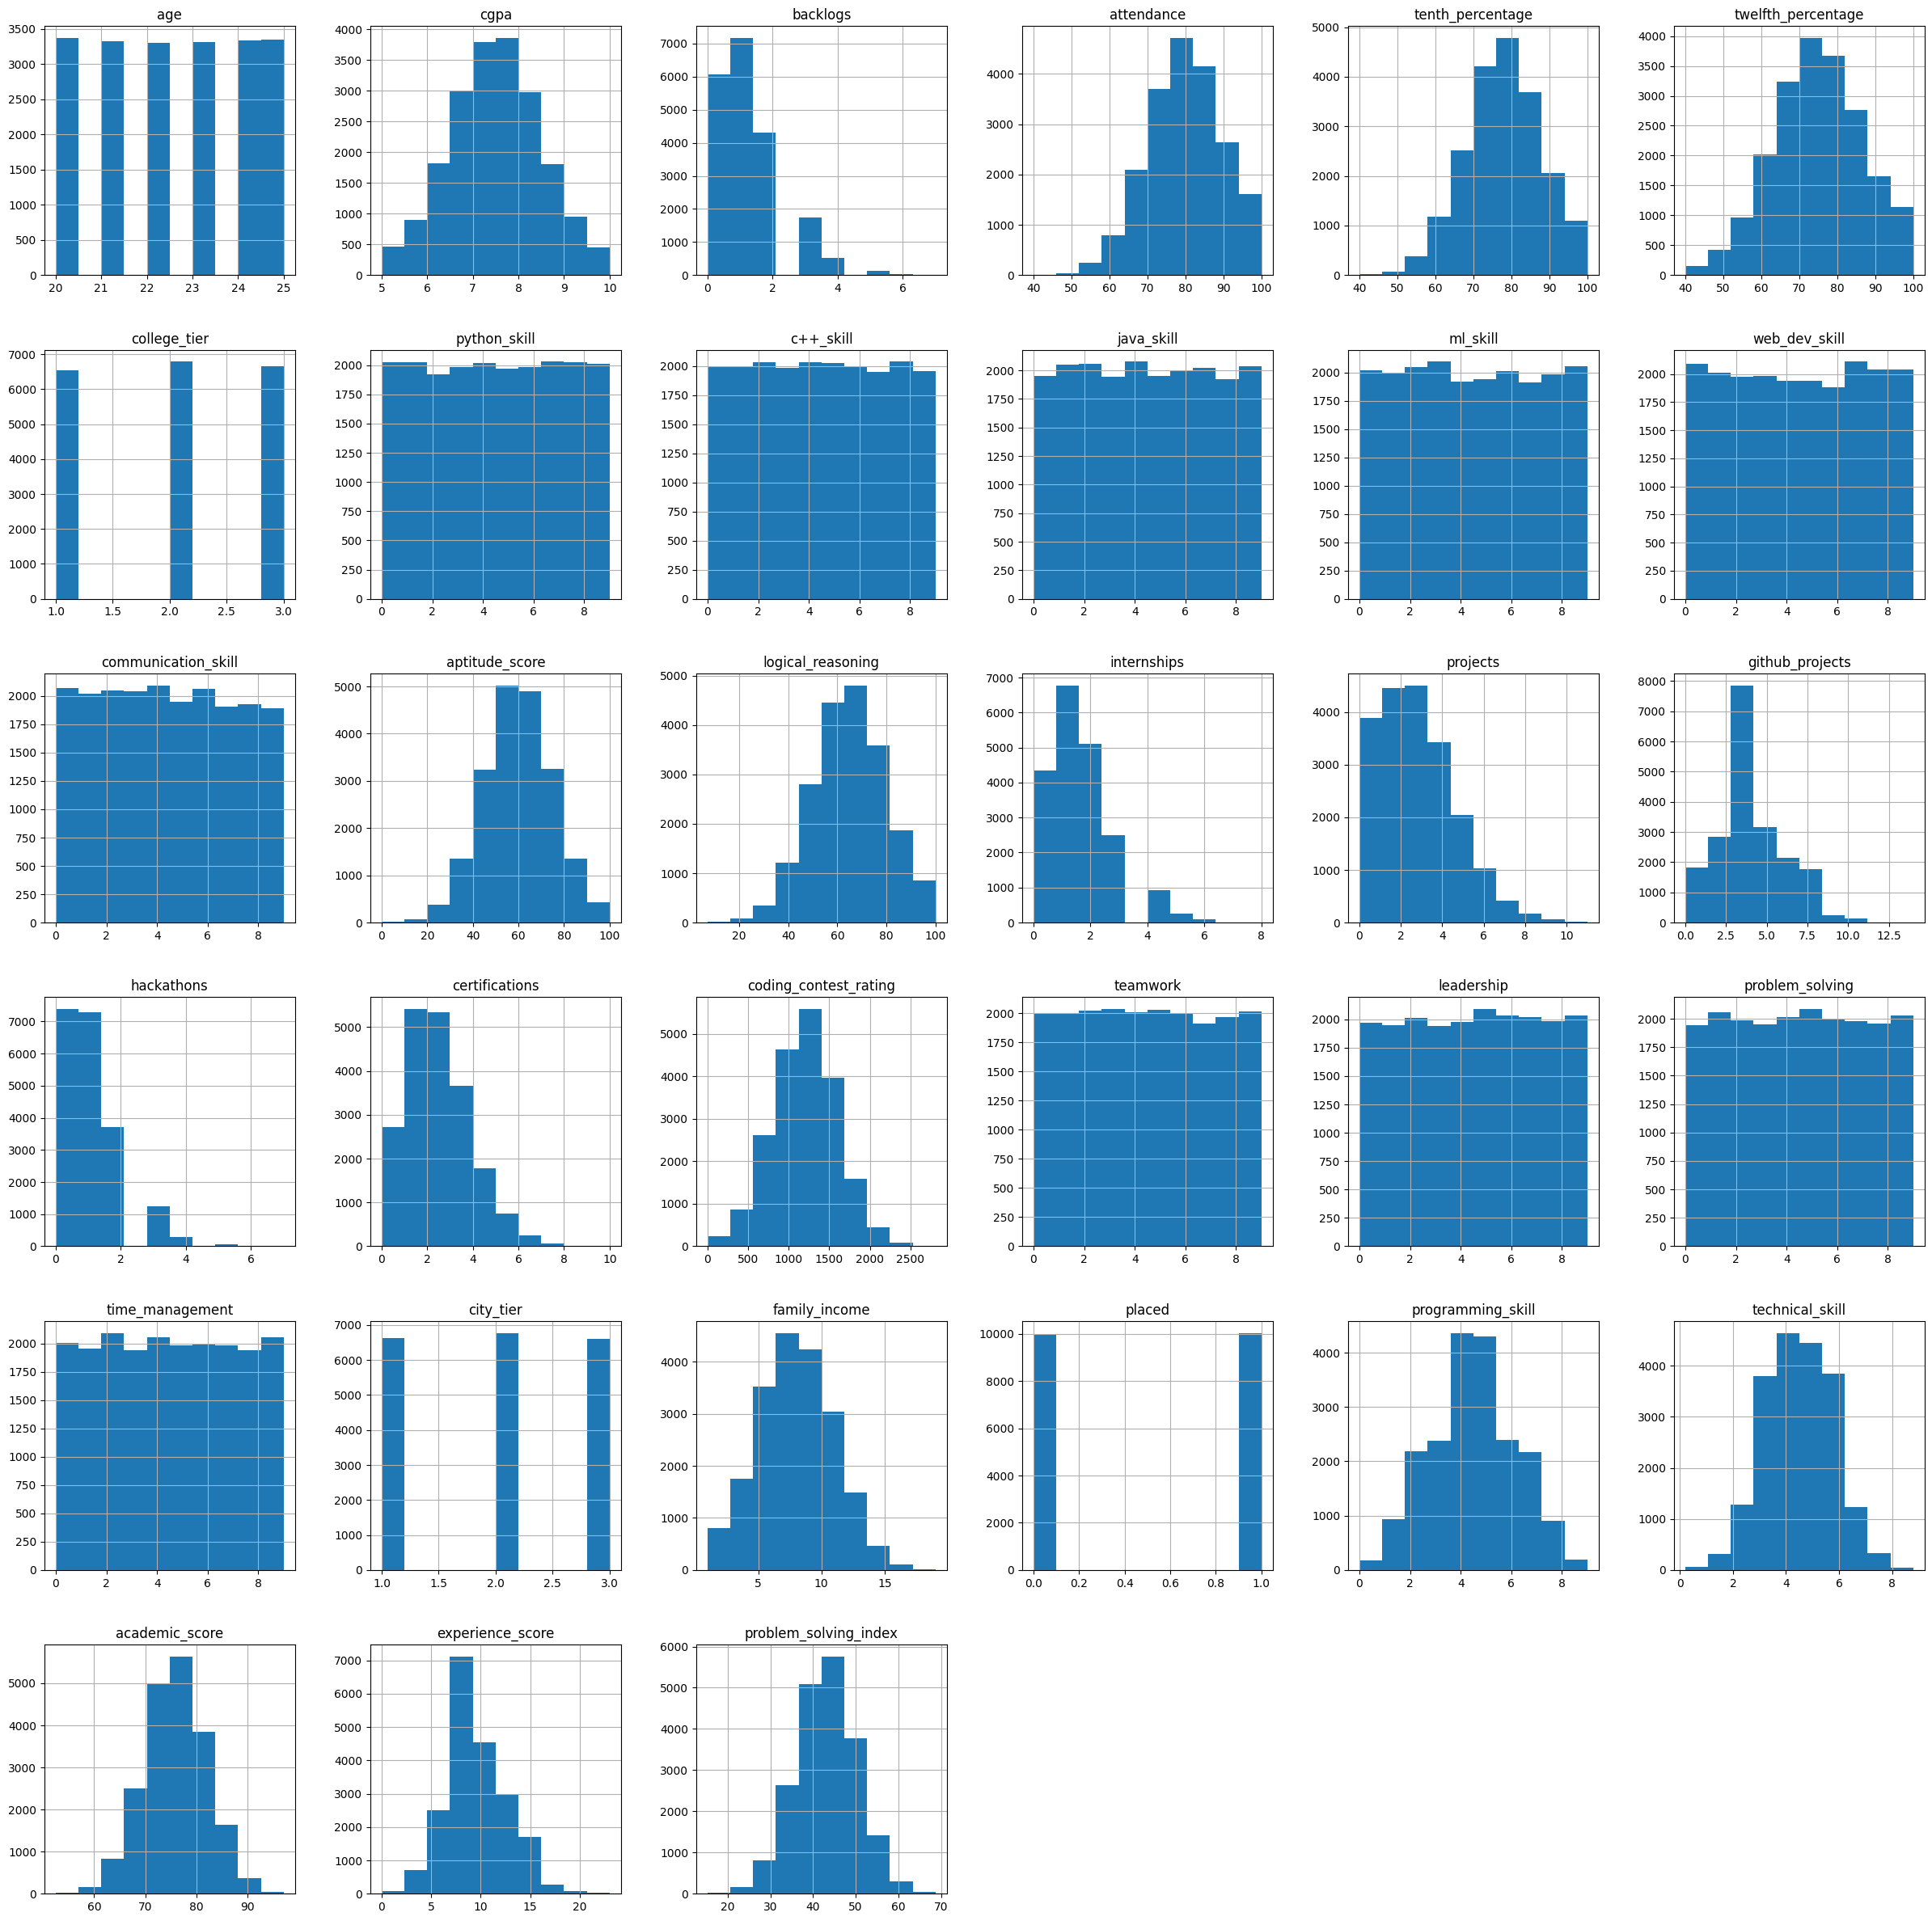

In [9]:
df.hist(figsize=(30,30));

<Axes: xlabel='placed'>

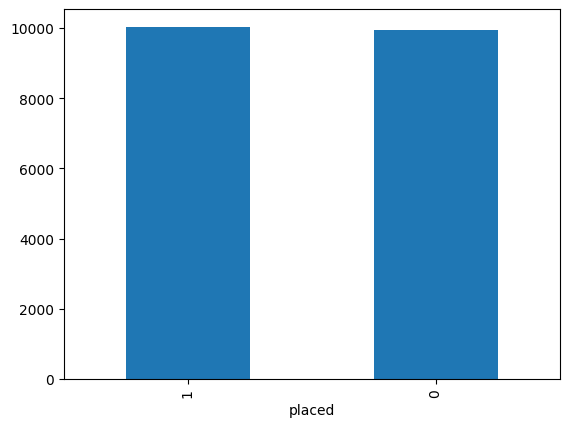

In [10]:
df["placed"].value_counts().plot(kind="bar")

In [11]:
df.corr(numeric_only=True)

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,college_tier,python_skill,c++_skill,java_skill,...,problem_solving,time_management,city_tier,family_income,placed,programming_skill,technical_skill,academic_score,experience_score,problem_solving_index
age,1.000000,-0.005525,-0.007365,0.012322,-0.002592,-0.007880,-0.001716,0.011190,0.001718,-0.010027,...,-0.002407,0.005194,0.013158,-0.010540,0.006078,0.001696,0.002406,-0.009541,0.005813,0.009399
cgpa,-0.005525,1.000000,-0.002513,-0.006155,-0.000446,-0.015363,0.005429,-0.001637,0.006446,0.005981,...,0.014129,0.004637,-0.005535,0.011204,0.115008,0.006242,0.003892,0.536995,-0.001884,0.004551
backlogs,-0.007365,-0.002513,1.000000,-0.005617,0.004397,-0.015040,0.001041,0.002988,-0.008646,-0.000714,...,0.001205,0.000970,0.003484,-0.001727,-0.043871,-0.003678,-0.013023,-0.008731,-0.007475,-0.003848
attendance,0.012322,-0.006155,-0.005617,1.000000,-0.005145,-0.002438,0.002694,0.006003,-0.003303,0.002743,...,-0.001933,-0.000096,0.007128,-0.013446,0.005016,0.003171,0.007416,-0.007748,-0.008757,0.002215
tenth_percentage,-0.002592,-0.000446,0.004397,-0.005145,1.000000,-0.006239,0.007472,0.005939,0.005814,0.009226,...,-0.002661,0.002457,0.005022,0.006570,-0.009053,0.012164,0.001092,0.539772,0.005898,-0.002945
twelfth_percentage,-0.007880,-0.015363,-0.015040,-0.002438,-0.006239,1.000000,0.013713,-0.006731,0.003963,-0.008568,...,-0.001065,-0.008145,0.000617,-0.014979,-0.001110,-0.006587,0.000644,0.636380,0.000128,-0.015799
college_tier,-0.001716,0.005429,0.001041,0.002694,0.007472,0.013713,1.000000,0.001730,-0.001847,-0.000134,...,0.001981,-0.001040,-0.010810,-0.002692,-0.001748,-0.000140,-0.003313,0.015925,-0.008076,0.002337
python_skill,0.011190,-0.001637,0.002988,0.006003,0.005939,-0.006731,0.001730,1.000000,-0.004695,-0.004244,...,-0.003170,0.001088,0.004325,-0.004249,0.146886,0.576685,0.443547,-0.002027,-0.000452,-0.007618
c++_skill,0.001718,0.006446,-0.008646,-0.003303,0.005814,0.003963,-0.001847,-0.004695,1.000000,-0.004423,...,-0.005433,-0.003674,0.005457,0.008882,0.139958,0.573295,0.436929,0.009259,0.004223,0.010270
java_skill,-0.010027,0.005981,-0.000714,0.002743,0.009226,-0.008568,-0.000134,-0.004244,-0.004423,1.000000,...,0.007512,0.008700,-0.000228,-0.000659,0.147366,0.574334,0.444594,0.002738,0.000031,-0.001752


Axes(0.125,0.11;0.62x0.77)


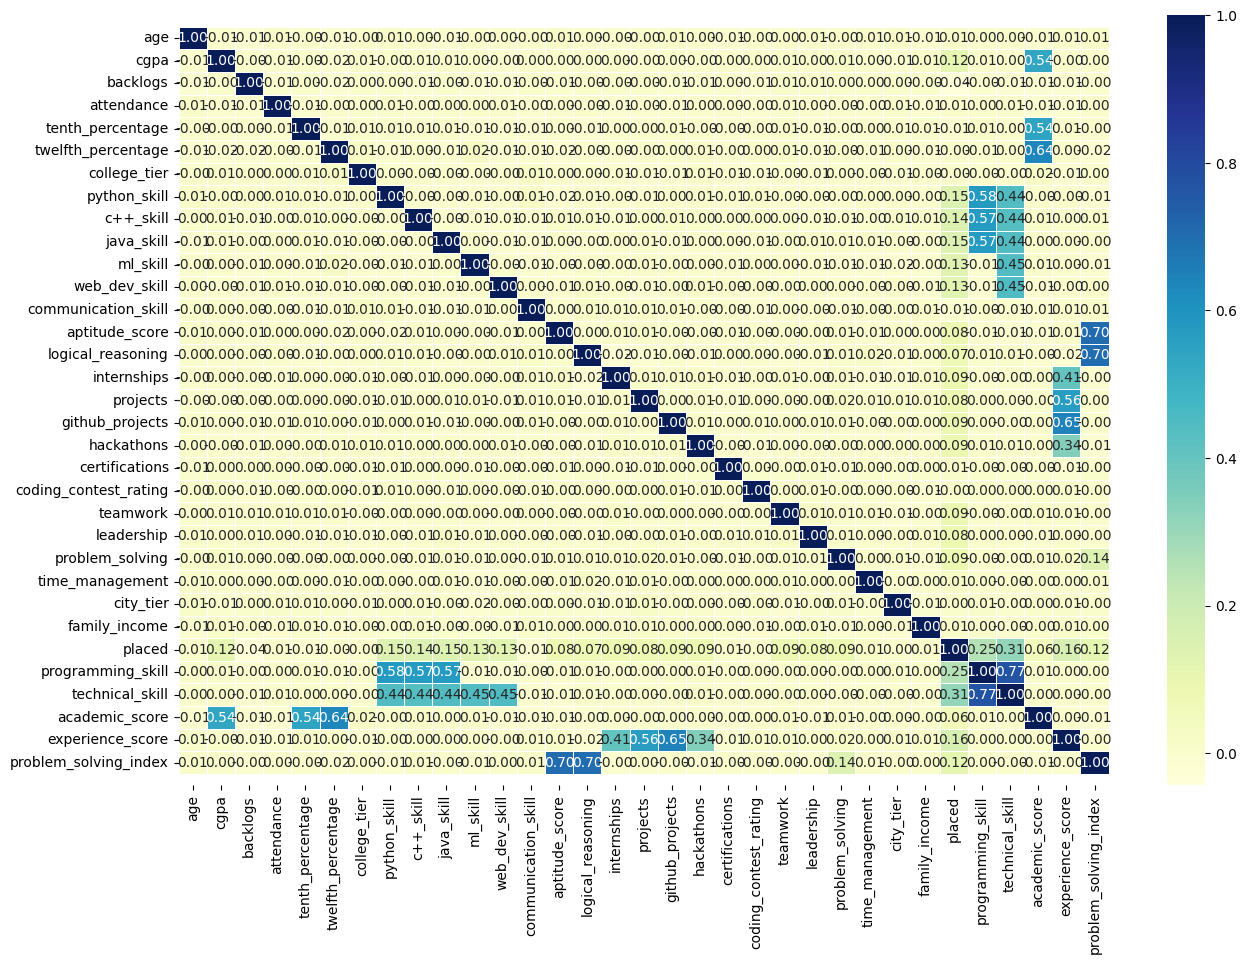

In [12]:
import seaborn as sns
fig,ax= plt.subplots(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),
           annot=True,
           fmt=".2f",
           linewidths=0.5,
           cmap="YlGnBu")

bottom,top = ax.get_ylim()
ax.set_ylim(bottom+0.5,top-0.5)
ax = plt.gca()
print(ax)


In [13]:
df.columns.tolist()

['age',
 'cgpa',
 'backlogs',
 'attendance',
 'tenth_percentage',
 'twelfth_percentage',
 'branch',
 'college_tier',
 'python_skill',
 'c++_skill',
 'java_skill',
 'ml_skill',
 'web_dev_skill',
 'communication_skill',
 'aptitude_score',
 'logical_reasoning',
 'internships',
 'projects',
 'github_projects',
 'hackathons',
 'certifications',
 'coding_contest_rating',
 'teamwork',
 'leadership',
 'problem_solving',
 'time_management',
 'gender',
 'city_tier',
 'family_income',
 'placed',
 'programming_skill',
 'technical_skill',
 'academic_score',
 'experience_score',
 'problem_solving_index']

In [14]:
df["python_skill"].value_counts() ,df["c++_skill"].value_counts(), df["java_skill"].value_counts(), df["ml_skill"].value_counts(), df["web_dev_skill"].value_counts()

(python_skill
 7    2030
 0    2028
 1    2024
 8    2023
 4    2018
 9    2015
 3    1985
 6    1982
 5    1972
 2    1923
 Name: count, dtype: int64,
 c++_skill
 8    2037
 4    2034
 2    2030
 5    2023
 6    2000
 0    1993
 1    1991
 3    1985
 9    1959
 7    1948
 Name: count, dtype: int64,
 java_skill
 4    2075
 2    2059
 1    2048
 9    2034
 7    2020
 6    1997
 5    1950
 0    1948
 3    1946
 8    1923
 Name: count, dtype: int64,
 ml_skill
 3    2097
 9    2056
 2    2052
 0    2023
 6    2013
 1    1991
 8    1984
 5    1945
 4    1922
 7    1917
 Name: count, dtype: int64,
 web_dev_skill
 7    2109
 0    2089
 8    2039
 9    2037
 1    2008
 3    1984
 2    1974
 4    1941
 5    1936
 6    1883
 Name: count, dtype: int64)

In [15]:
%%time
df["programming_skill"] = (df["python_skill"]+
                          df["c++_skill"]+
                          df["java_skill"])/3

CPU times: total: 0 ns
Wall time: 1 ms


In [16]:
df["programming_skill"].value_counts()

programming_skill
4.333333    1528
5.000000    1459
4.666667    1452
4.000000    1437
3.666667    1399
5.333333    1386
5.666667    1281
3.333333    1276
6.000000    1110
3.000000    1102
2.666667     919
6.333333     900
2.333333     713
6.666667     702
7.000000     573
2.000000     554
1.666667     441
7.333333     416
7.666667     305
1.333333     293
1.000000     197
8.000000     185
0.666667     118
8.333333     112
8.666667      60
0.333333      46
9.000000      18
0.000000      18
Name: count, dtype: int64

In [17]:
df.head()

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,branch,college_tier,python_skill,c++_skill,...,time_management,gender,city_tier,family_income,placed,programming_skill,technical_skill,academic_score,experience_score,problem_solving_index
0,22,6.92,0,73.671705,67.348211,92.107604,EE,3,5,5,...,9,Male,1,4.522336,1,6.333333,5.6,76.218605,12,46.022886
1,23,8.41,0,76.744599,83.436313,89.369896,CE,3,2,8,...,2,Female,3,8.775525,1,5.000000,5.0,85.635403,9,38.586494
2,21,7.70,1,85.945034,67.848361,73.393314,IT,3,9,4,...,3,Male,1,6.159067,1,5.666667,5.0,72.747225,12,58.874571
3,21,8.29,0,87.053234,69.491324,73.509382,ECE,2,4,7,...,8,Female,2,7.880186,0,4.666667,4.0,75.300235,6,54.172023
4,20,5.37,3,71.777160,72.859973,63.529267,ME,3,6,1,...,9,Female,1,7.711460,0,4.333333,5.0,63.363080,14,37.522803


In [18]:

df["technical_skill"] = (
    df["python_skill"] +
    df["java_skill"] +
    df["c++_skill"] +
    df["ml_skill"] +
    df["web_dev_skill"]
)/5

In [19]:
df.head()

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,branch,college_tier,python_skill,c++_skill,...,time_management,gender,city_tier,family_income,placed,programming_skill,technical_skill,academic_score,experience_score,problem_solving_index
0,22,6.92,0,73.671705,67.348211,92.107604,EE,3,5,5,...,9,Male,1,4.522336,1,6.333333,5.6,76.218605,12,46.022886
1,23,8.41,0,76.744599,83.436313,89.369896,CE,3,2,8,...,2,Female,3,8.775525,1,5.000000,5.0,85.635403,9,38.586494
2,21,7.70,1,85.945034,67.848361,73.393314,IT,3,9,4,...,3,Male,1,6.159067,1,5.666667,5.0,72.747225,12,58.874571
3,21,8.29,0,87.053234,69.491324,73.509382,ECE,2,4,7,...,8,Female,2,7.880186,0,4.666667,4.0,75.300235,6,54.172023
4,20,5.37,3,71.777160,72.859973,63.529267,ME,3,6,1,...,9,Female,1,7.711460,0,4.333333,5.0,63.363080,14,37.522803


In [20]:
df["academic_score"] = (
    df["cgpa"] * 10 +
    df["tenth_percentage"] +
    df["twelfth_percentage"]
)/3
df.head()

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,branch,college_tier,python_skill,c++_skill,...,time_management,gender,city_tier,family_income,placed,programming_skill,technical_skill,academic_score,experience_score,problem_solving_index
0,22,6.92,0,73.671705,67.348211,92.107604,EE,3,5,5,...,9,Male,1,4.522336,1,6.333333,5.6,76.218605,12,46.022886
1,23,8.41,0,76.744599,83.436313,89.369896,CE,3,2,8,...,2,Female,3,8.775525,1,5.000000,5.0,85.635403,9,38.586494
2,21,7.70,1,85.945034,67.848361,73.393314,IT,3,9,4,...,3,Male,1,6.159067,1,5.666667,5.0,72.747225,12,58.874571
3,21,8.29,0,87.053234,69.491324,73.509382,ECE,2,4,7,...,8,Female,2,7.880186,0,4.666667,4.0,75.300235,6,54.172023
4,20,5.37,3,71.777160,72.859973,63.529267,ME,3,6,1,...,9,Female,1,7.711460,0,4.333333,5.0,63.363080,14,37.522803


In [21]:
df.internships.value_counts(), df.projects.value_counts(), df.github_projects.value_counts(),df.hackathons.value_counts(), df["internships"].value_counts()

(internships
 1    6774
 2    5096
 0    4349
 3    2498
 4     925
 5     256
 6      86
 7      13
 8       3
 Name: count, dtype: int64,
 projects
 3     4505
 2     4453
 4     3420
 1     2904
 5     2043
 6     1032
 0      986
 7      419
 8      164
 9       56
 10      16
 11       2
 Name: count, dtype: int64,
 github_projects
 3     3955
 4     3902
 5     3161
 2     2844
 6     2142
 1     1447
 7     1182
 8      576
 0      372
 9      253
 10     106
 11      43
 12      12
 14       3
 13       2
 Name: count, dtype: int64,
 hackathons
 0    7385
 1    7293
 2    3706
 3    1242
 4     294
 5      68
 6       9
 7       3
 Name: count, dtype: int64,
 internships
 1    6774
 2    5096
 0    4349
 3    2498
 4     925
 5     256
 6      86
 7      13
 8       3
 Name: count, dtype: int64)

In [22]:
df["experience_score"] = (
    df["internships"] +
    df["projects"] +
    df["github_projects"] +
    df["hackathons"]
)

In [23]:
df.head()

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,branch,college_tier,python_skill,c++_skill,...,time_management,gender,city_tier,family_income,placed,programming_skill,technical_skill,academic_score,experience_score,problem_solving_index
0,22,6.92,0,73.671705,67.348211,92.107604,EE,3,5,5,...,9,Male,1,4.522336,1,6.333333,5.6,76.218605,12,46.022886
1,23,8.41,0,76.744599,83.436313,89.369896,CE,3,2,8,...,2,Female,3,8.775525,1,5.000000,5.0,85.635403,9,38.586494
2,21,7.70,1,85.945034,67.848361,73.393314,IT,3,9,4,...,3,Male,1,6.159067,1,5.666667,5.0,72.747225,12,58.874571
3,21,8.29,0,87.053234,69.491324,73.509382,ECE,2,4,7,...,8,Female,2,7.880186,0,4.666667,4.0,75.300235,6,54.172023
4,20,5.37,3,71.777160,72.859973,63.529267,ME,3,6,1,...,9,Female,1,7.711460,0,4.333333,5.0,63.363080,14,37.522803


In [24]:
df["problem_solving_index"] = (
    df["problem_solving"] +
    df["logical_reasoning"] +
    df["aptitude_score"]
)/3
df.head()

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,branch,college_tier,python_skill,c++_skill,...,time_management,gender,city_tier,family_income,placed,programming_skill,technical_skill,academic_score,experience_score,problem_solving_index
0,22,6.92,0,73.671705,67.348211,92.107604,EE,3,5,5,...,9,Male,1,4.522336,1,6.333333,5.6,76.218605,12,46.022886
1,23,8.41,0,76.744599,83.436313,89.369896,CE,3,2,8,...,2,Female,3,8.775525,1,5.000000,5.0,85.635403,9,38.586494
2,21,7.70,1,85.945034,67.848361,73.393314,IT,3,9,4,...,3,Male,1,6.159067,1,5.666667,5.0,72.747225,12,58.874571
3,21,8.29,0,87.053234,69.491324,73.509382,ECE,2,4,7,...,8,Female,2,7.880186,0,4.666667,4.0,75.300235,6,54.172023
4,20,5.37,3,71.777160,72.859973,63.529267,ME,3,6,1,...,9,Female,1,7.711460,0,4.333333,5.0,63.363080,14,37.522803


<Axes: xlabel='placed', ylabel='count'>

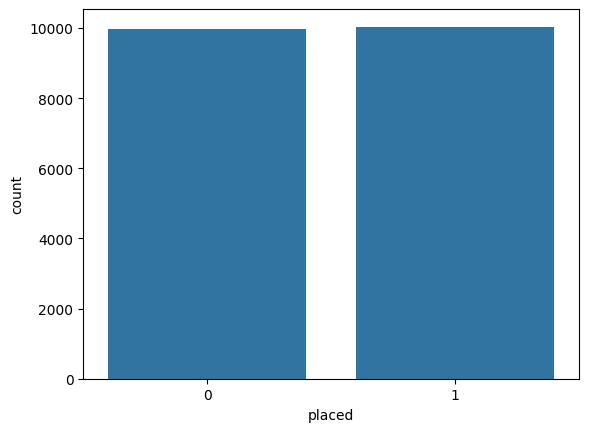

In [25]:
sns.countplot(x="placed",data=df)

Axes(0.125,0.11;0.62x0.77)


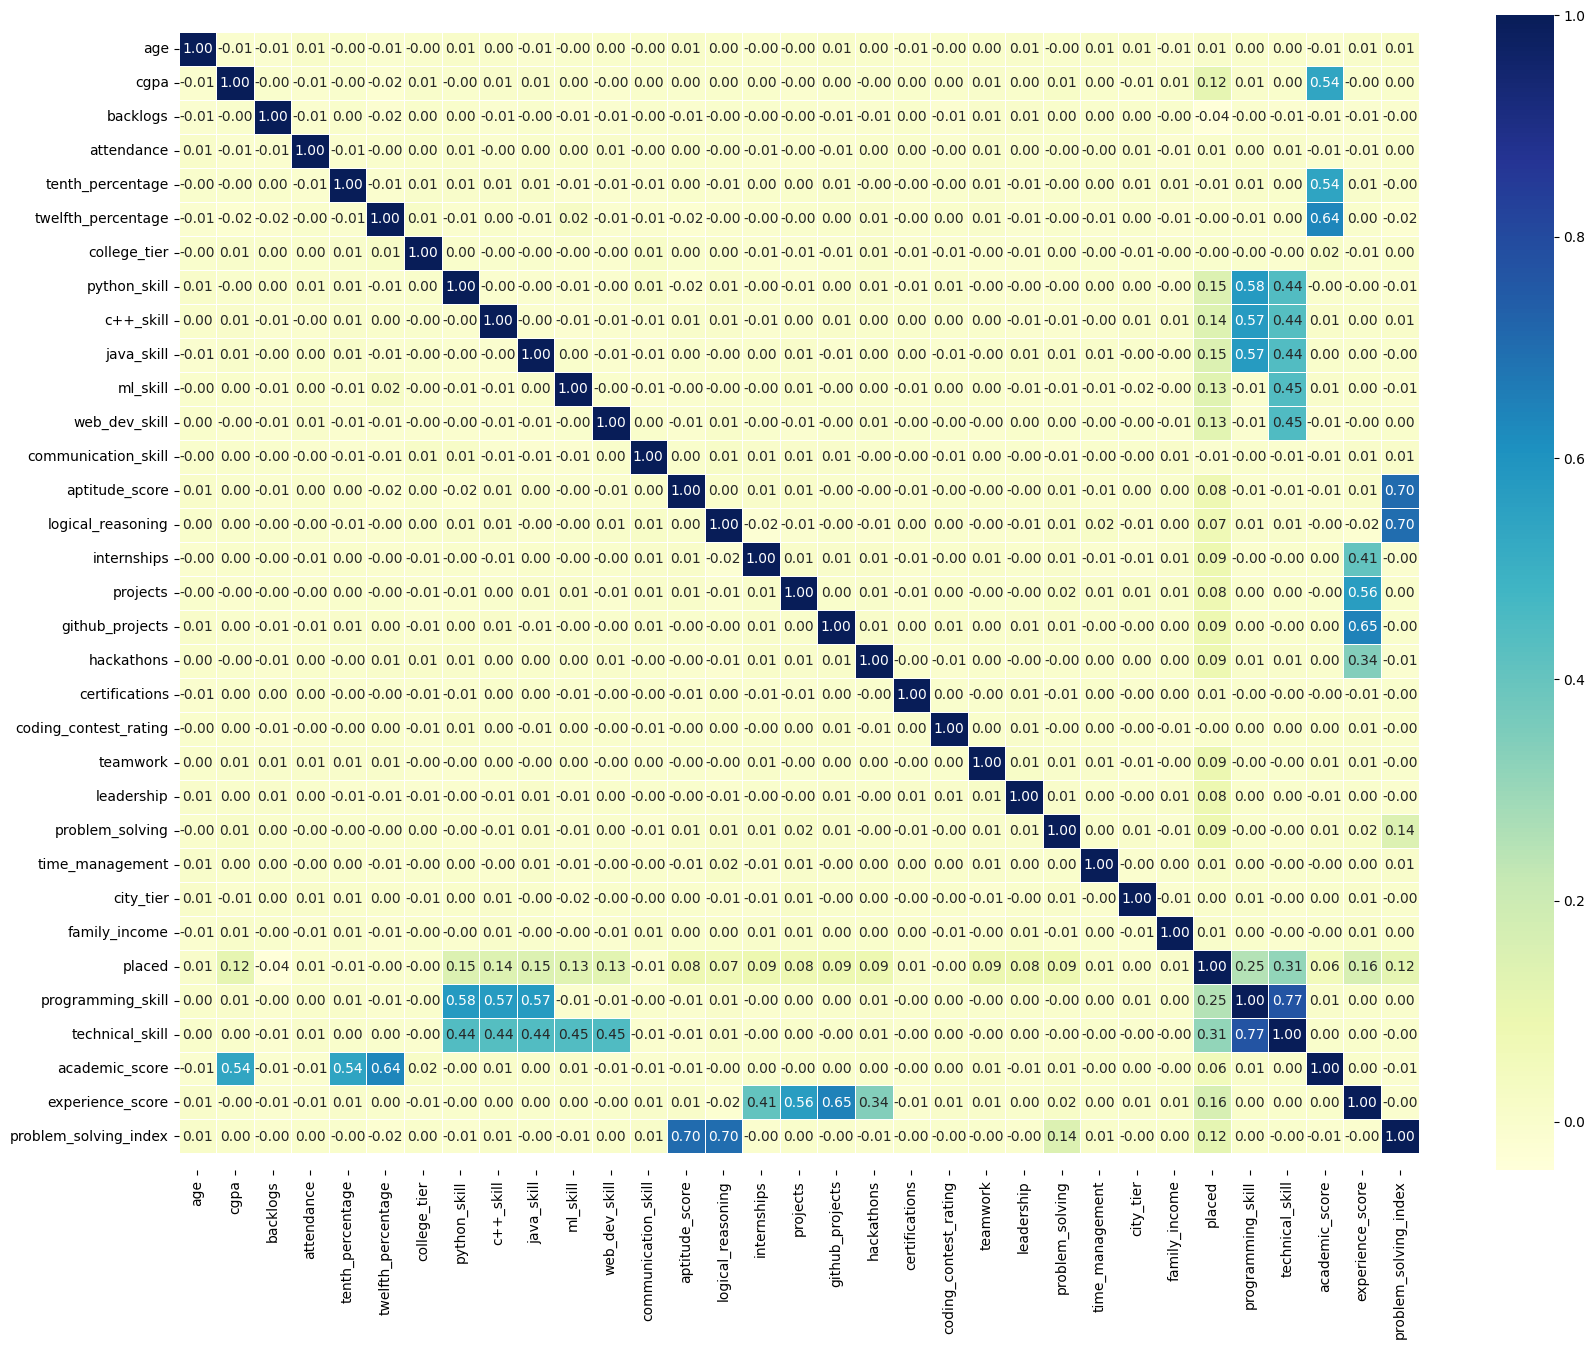

In [26]:
fig,ax = plt.subplots(figsize=(20,15))
sns.heatmap(df.corr(numeric_only=True),
           annot=True,
           fmt=".2f",
           linewidths=0.5,
           cmap="YlGnBu")
bottom,top = ax.get_ylim()
ax.set_ylim(bottom+0.5,top-0.5)
ax = plt.gca()
print(ax)

In [27]:
df.corr(numeric_only=True)["placed"].sort_values()

backlogs                -0.043871
tenth_percentage        -0.009053
communication_skill     -0.007175
college_tier            -0.001748
coding_contest_rating   -0.001564
twelfth_percentage      -0.001110
city_tier                0.003510
attendance               0.005016
age                      0.006078
family_income            0.006700
certifications           0.007540
time_management          0.013417
academic_score           0.057287
logical_reasoning        0.070617
projects                 0.080083
aptitude_score           0.081525
leadership               0.082704
hackathons               0.085827
github_projects          0.086252
internships              0.087398
problem_solving          0.089720
teamwork                 0.090787
cgpa                     0.115008
problem_solving_index    0.118398
web_dev_skill            0.126023
ml_skill                 0.132147
c++_skill                0.139958
python_skill             0.146886
java_skill               0.147366
experience_sco

In [28]:
df_sample = df.sample(n=20000, random_state=42)

In [29]:
df_sample.head()

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,branch,college_tier,python_skill,c++_skill,...,time_management,gender,city_tier,family_income,placed,programming_skill,technical_skill,academic_score,experience_score,problem_solving_index
10650,25,9.56,1,81.683476,81.022411,73.562248,IT,3,0,0,...,4,Female,3,6.689169,0,2.000000,4.2,83.394886,12,52.401927
2041,25,10.00,1,81.272574,71.048602,60.562863,CSE,3,4,1,...,0,Female,1,5.989734,1,2.666667,3.4,77.203822,6,38.906476
8668,22,6.12,1,84.872144,77.065783,50.384660,ME,1,3,6,...,6,Male,1,9.610968,1,5.000000,4.2,62.883481,7,50.939076
1114,24,8.56,0,74.686475,77.596394,78.386070,IT,1,0,6,...,1,Male,1,4.528241,1,3.000000,4.8,80.527488,8,48.726351
13902,20,7.47,0,70.304582,66.458917,78.166474,ECE,1,6,6,...,9,Male,1,10.042992,0,6.000000,6.0,73.108464,4,33.428614


In [30]:
df_sample.shape

(20000, 35)

In [31]:
df_sample.describe()

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,college_tier,python_skill,c++_skill,java_skill,...,problem_solving,time_management,city_tier,family_income,placed,programming_skill,technical_skill,academic_score,experience_score,problem_solving_index
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,...,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,22.497900,7.499086,1.202650,79.929242,77.965209,74.878126,2.005500,4.50890,4.491000,4.493300,...,4.50645,4.496250,1.998850,8.008244,0.501900,4.497733,4.495940,75.944730,9.53025,43.102798
std,1.712467,0.994084,1.106004,9.792943,9.883886,11.775437,0.812713,2.88169,2.865489,2.869315,...,2.86595,2.874352,0.813192,2.984741,0.500009,1.650848,1.276977,6.055629,3.10317,7.091876
min,20.000000,5.000000,0.000000,40.000000,40.000000,40.000000,1.000000,0.00000,0.000000,0.000000,...,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.200000,52.496710,0.00000,15.315324
25%,21.000000,6.820000,0.000000,73.326385,71.347185,66.874507,1.000000,2.00000,2.000000,2.000000,...,2.00000,2.000000,1.000000,5.932038,0.000000,3.333333,3.600000,71.855132,7.00000,38.374298
50%,22.000000,7.500000,1.000000,79.967806,78.017561,74.818776,2.000000,5.00000,4.000000,4.000000,...,5.00000,4.000000,2.000000,7.970676,1.000000,4.333333,4.400000,75.925470,9.00000,43.138158
75%,24.000000,8.170000,2.000000,86.832208,84.761382,83.013011,3.000000,7.00000,7.000000,7.000000,...,7.00000,7.000000,3.000000,10.062760,1.000000,5.666667,5.400000,80.038656,12.00000,47.898178
max,25.000000,10.000000,7.000000,100.000000,100.000000,100.000000,3.000000,9.00000,9.000000,9.000000,...,9.00000,9.000000,3.000000,19.015142,1.000000,9.000000,8.800000,97.056756,23.00000,68.666667


In [32]:
df_sample.dtypes

age                        int64
cgpa                     float64
backlogs                   int64
attendance               float64
tenth_percentage         float64
twelfth_percentage       float64
branch                       str
college_tier               int64
python_skill               int64
c++_skill                  int64
java_skill                 int64
ml_skill                   int64
web_dev_skill              int64
communication_skill        int64
aptitude_score           float64
logical_reasoning        float64
internships                int64
projects                   int64
github_projects            int64
hackathons                 int64
certifications             int64
coding_contest_rating    float64
teamwork                   int64
leadership                 int64
problem_solving            int64
time_management            int64
gender                       str
city_tier                  int64
family_income            float64
placed                     int64
programmin

In [33]:
df.shape, df_sample.shape

((20000, 35), (20000, 35))

In [34]:
df_sample.select_dtypes(include="object").columns.tolist()

C:\Users\MOHAMMAD ISMAIL\AppData\Local\Temp\ipykernel_25336\2311084774.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_sample.select_dtypes(include="object").columns.tolist()


['branch', 'gender']

In [35]:
df_sample = pd.get_dummies(df_sample,
                          columns=['branch', 'gender'],
                           drop_first=True
                          )

In [36]:
df_sample.head()

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,college_tier,python_skill,c++_skill,java_skill,...,technical_skill,academic_score,experience_score,problem_solving_index,branch_CSE,branch_ECE,branch_EE,branch_IT,branch_ME,gender_Male
10650,25,9.56,1,81.683476,81.022411,73.562248,3,0,0,6,...,4.2,83.394886,12,52.401927,False,False,False,True,False,False
2041,25,10.00,1,81.272574,71.048602,60.562863,3,4,1,3,...,3.4,77.203822,6,38.906476,True,False,False,False,False,False
8668,22,6.12,1,84.872144,77.065783,50.384660,1,3,6,6,...,4.2,62.883481,7,50.939076,False,False,False,False,True,True
1114,24,8.56,0,74.686475,77.596394,78.386070,1,0,6,3,...,4.8,80.527488,8,48.726351,False,False,False,True,False,True
13902,20,7.47,0,70.304582,66.458917,78.166474,1,6,6,6,...,6.0,73.108464,4,33.428614,False,True,False,False,False,True


In [37]:
df_sample.dtypes

age                        int64
cgpa                     float64
backlogs                   int64
attendance               float64
tenth_percentage         float64
twelfth_percentage       float64
college_tier               int64
python_skill               int64
c++_skill                  int64
java_skill                 int64
ml_skill                   int64
web_dev_skill              int64
communication_skill        int64
aptitude_score           float64
logical_reasoning        float64
internships                int64
projects                   int64
github_projects            int64
hackathons                 int64
certifications             int64
coding_contest_rating    float64
teamwork                   int64
leadership                 int64
problem_solving            int64
time_management            int64
city_tier                  int64
family_income            float64
placed                     int64
programming_skill        float64
technical_skill          float64
academic_s

In [38]:
df_sample.shape

(20000, 39)

In [39]:
X = df_sample.drop("placed",axis=1)
y = df_sample["placed"]

In [40]:
X

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,college_tier,python_skill,c++_skill,java_skill,...,technical_skill,academic_score,experience_score,problem_solving_index,branch_CSE,branch_ECE,branch_EE,branch_IT,branch_ME,gender_Male
10650,25,9.56,1,81.683476,81.022411,73.562248,3,0,0,6,...,4.2,83.394886,12,52.401927,False,False,False,True,False,False
2041,25,10.00,1,81.272574,71.048602,60.562863,3,4,1,3,...,3.4,77.203822,6,38.906476,True,False,False,False,False,False
8668,22,6.12,1,84.872144,77.065783,50.384660,1,3,6,6,...,4.2,62.883481,7,50.939076,False,False,False,False,True,True
1114,24,8.56,0,74.686475,77.596394,78.386070,1,0,6,3,...,4.8,80.527488,8,48.726351,False,False,False,True,False,True
13902,20,7.47,0,70.304582,66.458917,78.166474,1,6,6,6,...,6.0,73.108464,4,33.428614,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,24,8.23,1,73.431969,72.837219,96.973936,2,3,1,3,...,3.4,84.037052,8,38.995980,False,True,False,False,False,True
11964,23,9.06,0,77.812138,93.124023,53.461876,2,7,4,8,...,7.0,79.061966,12,49.087171,False,False,False,True,False,True
5390,20,7.34,2,82.623135,85.937167,55.850589,2,7,9,0,...,5.2,71.729252,9,53.379927,False,False,False,True,False,False
860,24,7.86,2,74.344452,75.808412,60.266154,2,9,7,8,...,7.0,71.558188,10,45.314020,False,True,False,False,False,True


In [41]:
y

10650    0
2041     1
8668     1
1114     1
13902    0
        ..
11284    0
11964    1
5390     1
860      1
15795    1
Name: placed, Length: 20000, dtype: int64

In [42]:
df_sample.shape, X.shape, y.shape

((20000, 39), (20000, 38), (20000,))

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,
                                                y,
                                                test_size=0.2,
                                                random_state=42)

In [44]:
X_train.shape ,X_test.shape ,y_train.shape ,y_test.shape

((16000, 38), (4000, 38), (16000,), (4000,))

In [45]:
pipelines = {

    "Logistic Regression" : Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "KNN" : Pipeline([
        ("scaler",StandardScaler()),
        ("model",KNeighborsClassifier())
    ]),

    "Decision Tree" : Pipeline([
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest" : Pipeline([
        ("model",RandomForestClassifier(random_state=42))
    ])


    
}

In [46]:
%%time
result = []
for name,pipe in pipelines.items():
    pipe.fit(X_train,y_train)
    y_pred = pipe.predict(X_test)
    result.append({
        "Model" : name,
        "Accuracy" :  accuracy_score(y_test,y_pred)
    })
    print(name)
    print(classification_report(y_test,y_pred))

result
result_df = pd.DataFrame(result)
result_df


Logistic Regression
              precision    recall  f1-score   support

           0       0.67      0.68      0.67      1954
           1       0.69      0.68      0.68      2046

    accuracy                           0.68      4000
   macro avg       0.68      0.68      0.68      4000
weighted avg       0.68      0.68      0.68      4000

KNN
              precision    recall  f1-score   support

           0       0.59      0.61      0.60      1954
           1       0.62      0.60      0.61      2046

    accuracy                           0.60      4000
   macro avg       0.60      0.60      0.60      4000
weighted avg       0.60      0.60      0.60      4000

Decision Tree
              precision    recall  f1-score   support

           0       0.56      0.57      0.57      1954
           1       0.59      0.58      0.58      2046

    accuracy                           0.57      4000
   macro avg       0.57      0.57      0.57      4000
weighted avg       0.57      0.57   

,Model,Accuracy
0,Logistic Regression,0.67850
1,KNN,0.60450
2,Decision Tree,0.57475
3,Random Forest,0.66425


In [47]:
%%time
for name,pipe in pipelines.items():
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5
    )

    print(name)
    print(scores)
    print(f"Mean : {scores.mean()}")

Logistic Regression
[0.679375  0.66125   0.6690625 0.6675    0.685625 ]
Mean : 0.6725625
KNN
[0.59375   0.581875  0.5853125 0.575     0.5853125]
Mean : 0.58425
Decision Tree
[0.5675    0.5721875 0.5790625 0.56375   0.5659375]
Mean : 0.5696874999999999
Random Forest
[0.675625  0.66125   0.651875  0.6559375 0.6675   ]
Mean : 0.6624375
CPU times: total: 21.8 s
Wall time: 19.8 s


# Hyperparameter Tuning - Random Forest

In [48]:
LogisticRegression?

Init signature:
LogisticRegression(
    penalty='deprecated',
    *,
    C=1.0,
    l1_ratio=0.0,
    dual=False,
    tol=0.0001,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='lbfgs',
    max_iter=100,
    verbose=0,
    warm_start=False,
    n_jobs=None,
)
Docstring:     
Logistic Regression (aka logit, MaxEnt) classifier.

This class implements regularized logistic regression using a set of available
solvers. **Note that regularization is applied by default**. It can handle both
dense and sparse input `X`. Use C-ordered arrays or CSR matrices containing 64-bit
floats for optimal performance; any other input format will be converted (and
copied).

The solvers 'lbfgs', 'newton-cg', 'newton-cholesky' and 'sag' support only L2
regularization with primal formulation, or no regularization. The 'liblinear'
solver supports both L1 and L2 regularization (but not both, i.e. elastic-net),
with a dual formulation only for the L2 penalt

In [49]:
log_pipe = pipelines["Logistic Regression"]

In [50]:
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    # "model__C": np.logspace(-4,4,30),
    "model__solver": [
        "lbfgs",
        "liblinear",
        "newton-cg",
        "newton-cholesky"
    ]
}

In [51]:
print(LogisticRegression().get_params())

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 100, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [52]:
grid = GridSearchCV(
    estimator=log_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

In [53]:
%%time
grid.fit(X_train,y_train)

CPU times: total: 12.7 s
Wall time: 11.4 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.001, 0.01, ...], 'model__solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the

## Hyperparameter Tuning - Logistic Regression

The initial Logistic Regression model was trained using the default hyperparameters.

To improve the model's performance, GridSearchCV with 5-fold cross-validation was used to search for the optimal values of the regularization parameter (`C`) and optimization algorithm (`solver`).

### Best Hyperparameters
- C = 0.001
- Solver = liblinear

### Best Cross Validation Accuracy
67.37%

The tuned model was then evaluated on the unseen test dataset to measure its generalization performance.

In [54]:
print(grid.best_params_)

{'model__C': 0.01, 'model__solver': 'liblinear'}


In [55]:
print(grid.best_score_)

0.673375


In [56]:
best_model = grid.best_estimator_
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](38,)","['age','cgpa','backlogs',...,'branch_IT','branch_ME','gender_Male']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,38
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [57]:
y_pred = best_model.predict(X_test)

In [58]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      0.67      0.67      1954
           1       0.69      0.68      0.68      2046

    accuracy                           0.68      4000
   macro avg       0.68      0.68      0.68      4000
weighted avg       0.68      0.68      0.68      4000



In [59]:
accuracy_score(y_test, y_pred)


0.678

In [60]:
print(confusion_matrix(y_test,y_pred))


[[1314  640]
 [ 648 1398]]


# Hyperparameter Tuning - Random Forest

Random Forest contains several hyperparameters that influence model complexity and prediction performance.

Instead of using GridSearchCV, RandomizedSearchCV was selected because it evaluates a random subset of parameter combinations, making it significantly faster while still finding near-optimal hyperparameters.

In [61]:
RandomForestClassifier?

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the

In [62]:
rf_pipe = pipelines["Random Forest"]

In [63]:
RandomizedSearchCV?

Init signature:
RandomizedSearchCV(
    estimator,
    param_distributions,
    *,
    n_iter=10,
    scoring=None,
    n_jobs=None,
    refit=True,
    cv=None,
    verbose=0,
    pre_dispatch='2*n_jobs',
    random_state=None,
    error_score=nan,
    return_train_score=False,
)
Docstring:     
Randomized search on hyper parameters.

RandomizedSearchCV implements a "fit" and a "score" method.
It also implements "score_samples", "predict", "predict_proba",
"decision_function", "transform" and "inverse_transform" if they are
implemented in the estimator used.

The parameters of the estimator used to apply these methods are optimized
by cross-validated search over parameter settings.

In contrast to GridSearchCV, not all parameter values are tried out, but
rather a fixed number of parameter settings is sampled from the specified
distributions. The number of parameter settings that are tried is
given by n_iter.

If all parameters are presented as a list,
sampling without replacement is p

In [64]:
param_distributions = {
    "model__n_estimators" : [100,200,300,400,500],
    "model__max_depth": [None,10,20,30,40],
    "model__min_samples_split": [2,5,10],
    "model__min_samples_leaf": [1,2,4],
    "model__max_features": ["sqrt", "log2"]
}

In [65]:
print(RandomForestClassifier().get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [66]:
random_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    n_jobs=-1,
    cv=5,
    scoring="accuracy",
    random_state=42
)

In [67]:
random_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Ran

In [68]:
print(random_search.best_params_)

{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10}


In [69]:
print(random_search.best_score_)

0.666


## Best Random Forest Model

RandomizedSearchCV identified the best combination of hyperparameters using 5-fold cross-validation.

The tuned model was evaluated on the test dataset and compared with the Logistic Regression model.

In [70]:
best_rf_model = random_search.best_estimator_
best_rf_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](38,)","['age','cgpa','backlogs',...,'branch_IT','branch_ME','gender_Male']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,38
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10


In [71]:
rf_pred = best_rf_model.predict(X_test)

In [72]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.66      0.67      0.67      1954
           1       0.68      0.67      0.68      2046

    accuracy                           0.67      4000
   macro avg       0.67      0.67      0.67      4000
weighted avg       0.67      0.67      0.67      4000



In [73]:
accuracy_score(y_test,rf_pred)

0.6735

In [74]:
print(confusion_matrix(y_test,rf_pred))

[[1317  637]
 [ 669 1377]]


# Model Comparison

The following models were trained and evaluated for predicting student placement.

| Model | Accuracy |
|-------|---------|
| Logistic Regression | 67.93% |
| KNN | 59.38% |
| Decision Tree | 57.45% |
| Random Forest | 66.32% |
| Tuned Logistic Regression | 67.93% |
| Tuned Random Forest | 67.77 |

In [75]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regreesion(Tuned)",
        "Random Forest(Tuned)"
    ],

    "Accuracy": [
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,rf_pred)
    ]    
})

In [76]:
comparison

,Model,Accuracy
0,Logistic Regreesion(Tuned),0.6780
1,Random Forest(Tuned),0.6735


In [77]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Tuned Logistic Regression",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        0.67925,
        0.59375,
        0.57450,
        0.66325,
        0.67925,
        0.67775
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.67925
1,KNN,0.59375
2,Decision Tree,0.57450
3,Random Forest,0.66325
4,Tuned Logistic Regression,0.67925
5,Tuned Random Forest,0.67775


<Axes: title={'center': 'Comparison'}, xlabel='Model'>

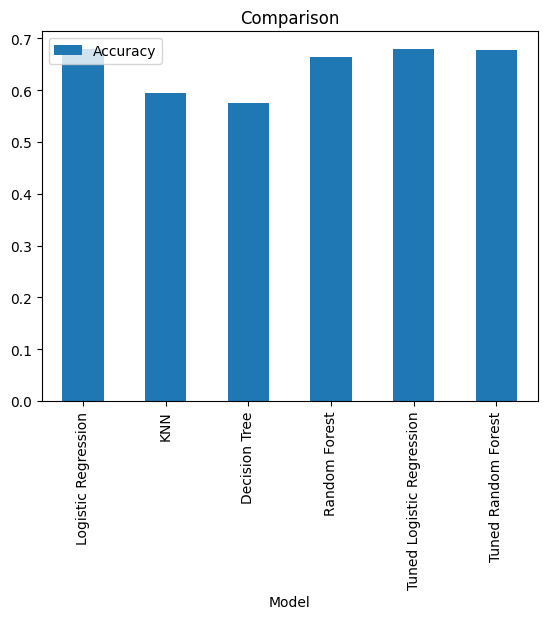

In [78]:
comparison.plot(kind="bar",title="Comparison",x= "Model")

# Final Model Evaluation

In [79]:
accuracy_score(y_test,y_pred)

0.678

In [80]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      0.67      0.67      1954
           1       0.69      0.68      0.68      2046

    accuracy                           0.68      4000
   macro avg       0.68      0.68      0.68      4000
weighted avg       0.68      0.68      0.68      4000



In [81]:
print(confusion_matrix(y_test,y_pred))

[[1314  640]
 [ 648 1398]]


## ROC Curve & AUC Score

In [82]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

AUC Score: 0.7485897539798554


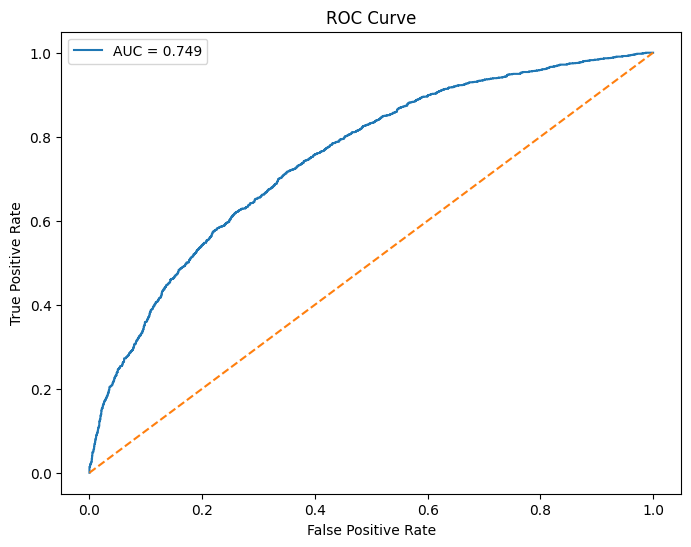

In [83]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

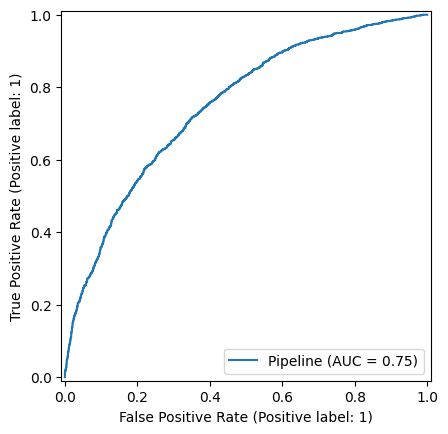

In [84]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

# Feature Importance Analysis

Random Forest provides feature importance scores that indicate how much each feature contributes to the prediction.

Features with higher importance have a greater influence on determining whether a student is placed or not.

This analysis helps identify the most influential academic, technical, and personal factors affecting campus placement.

In [85]:
rf_model = best_rf_model.named_steps["model"]

In [86]:
feature_importance = rf_model.feature_importances_

In [87]:
feature_importance

array([0.00993515, 0.05637779, 0.00999769, 0.02911746, 0.02931777,
       0.02930456, 0.00522081, 0.02401141, 0.0248764 , 0.0282121 ,
       0.03015177, 0.02659314, 0.013855  , 0.03855523, 0.03610904,
       0.01450852, 0.01544027, 0.01746179, 0.01337215, 0.0104959 ,
       0.03017751, 0.02659283, 0.02602015, 0.02776196, 0.01396633,
       0.00541255, 0.02954684, 0.06953082, 0.15215386, 0.0325527 ,
       0.05609395, 0.05121208, 0.00255441, 0.00262037, 0.0025054 ,
       0.002823  , 0.0026057 , 0.0029556 ])

In [88]:
feature_importance.shape

(38,)

In [89]:

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
})

In [90]:
importance_df

,Feature,Importance
0,age,0.009935
1,cgpa,0.056378
2,backlogs,0.009998
3,attendance,0.029117
4,tenth_percentage,0.029318
5,twelfth_percentage,0.029305
6,college_tier,0.005221
7,python_skill,0.024011
8,c++_skill,0.024876
9,java_skill,0.028212


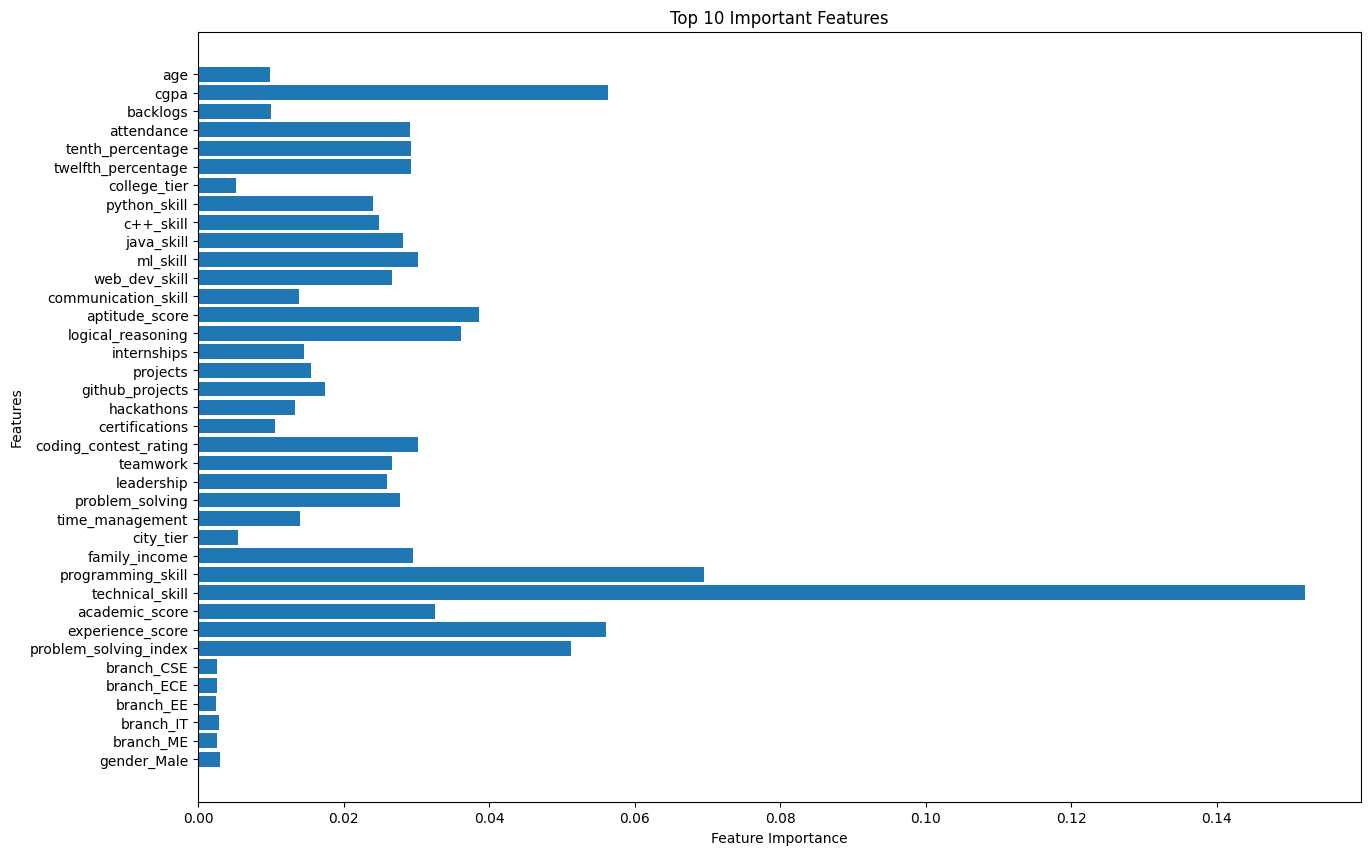

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [92]:
fr_model = best_model.named_steps["model"]
fr_model.coef_

array([[ 0.0045287 ,  0.22601242, -0.09623587,  0.01695423, -0.05552593,
        -0.0301205 , -0.00644178,  0.10152498,  0.09733525,  0.10731302,
         0.18924828,  0.160325  , -0.0128691 ,  0.09479644,  0.06291315,
         0.13083883,  0.07236424,  0.08132364,  0.1262712 ,  0.03141944,
        -0.01258009,  0.2048031 ,  0.18985624,  0.19622549,  0.04052032,
         0.01997398,  0.01193459,  0.17745462,  0.29539887,  0.07319169,
         0.18434888,  0.13724871, -0.00122579, -0.0233681 , -0.00216614,
        -0.00554043, -0.01046127, -0.02148877]])

In [93]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": fr_model.coef_[0]
})

In [94]:
coef_sort = coef_df.sort_values("Coefficient",ascending=False)
coef_sort

,Feature,Coefficient
28,technical_skill,0.295399
1,cgpa,0.226012
21,teamwork,0.204803
23,problem_solving,0.196225
22,leadership,0.189856
10,ml_skill,0.189248
30,experience_score,0.184349
27,programming_skill,0.177455
11,web_dev_skill,0.160325
31,problem_solving_index,0.137249


<Axes: title={'center': 'Feature Importance'}, xlabel='Feature'>

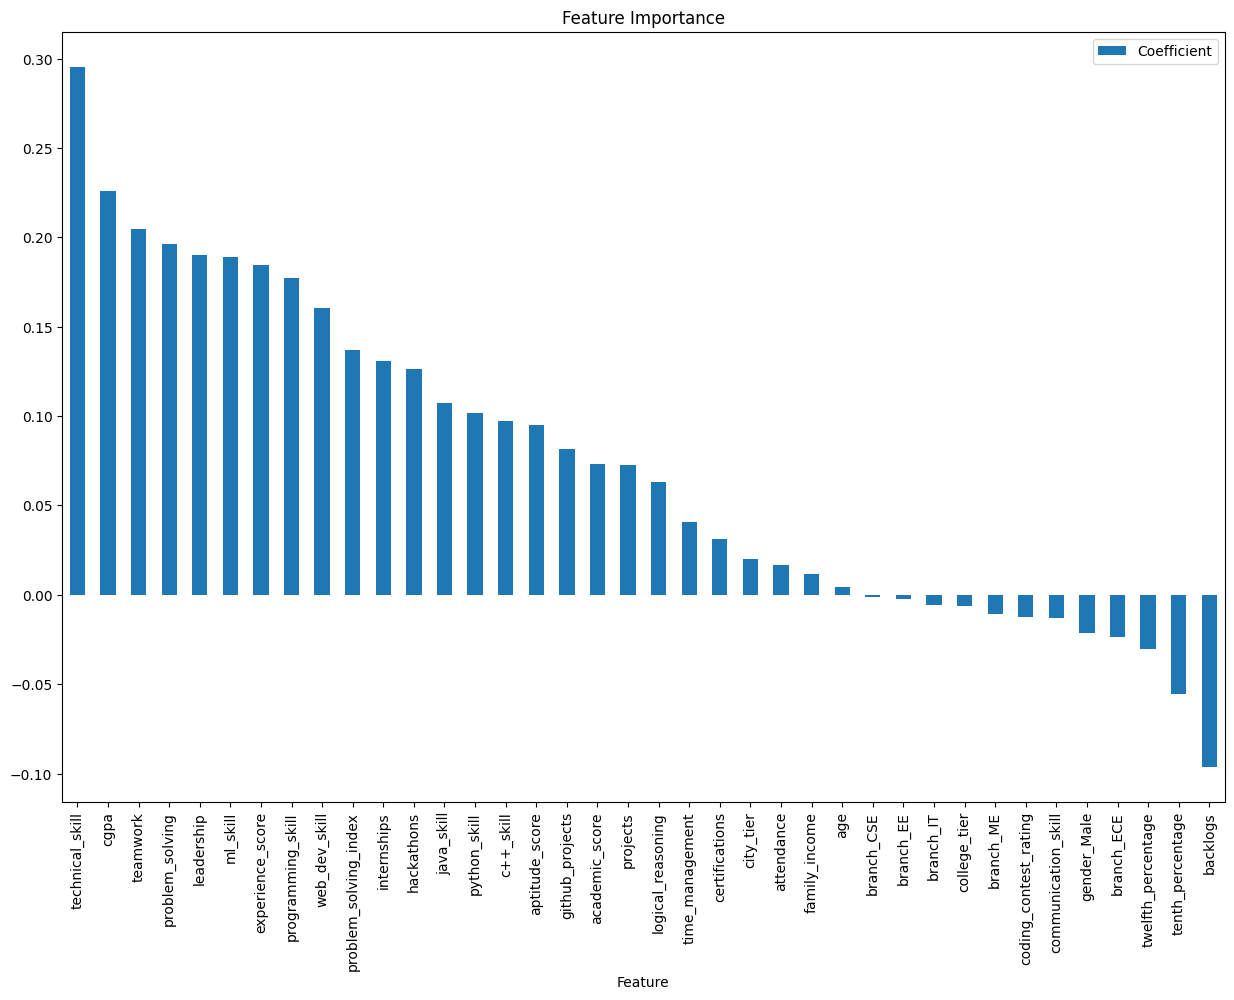

In [95]:
coef_sort.plot.bar(title="Feature Importance",x="Feature",figsize=(15,10))

# Conclusion

A complete machine learning pipeline was implemented to predict student placement.

The project included:

- Data preprocessing
- Feature engineering
- One-Hot Encoding
- Model training
- Cross-validation
- Hyperparameter tuning using GridSearchCV and RandomizedSearchCV

Among all the models, Logistic Regression achieved the best overall performance with an accuracy of approximately 68%.

The final tuned model can be saved and deployed for predicting placement outcomes of new students.

In [96]:
import joblib

In [97]:
joblib.dump(best_model, "placement_prediction_model.pkl")

['placement_prediction_model.pkl']

In [98]:
cols = [
    "communication_skill",
    "aptitude_score",
    "logical_reasoning",
    "python_skill",
    "java_skill",
    "c++_skill",
    "ml_skill",
    "web_dev_skill",
    "teamwork",
    "leadership",
    "problem_solving",
    "time_management"
]

print(df[cols].describe().loc[["min", "max"]])

     communication_skill  aptitude_score  logical_reasoning  python_skill  \
min                  0.0             0.0           7.093118           0.0   
max                  9.0           100.0         100.000000           9.0   

     java_skill  c++_skill  ml_skill  web_dev_skill  teamwork  leadership  \
min         0.0        0.0       0.0            0.0       0.0         0.0   
max         9.0        9.0       9.0            9.0       9.0         9.0   

     problem_solving  time_management  
min              0.0              0.0  
max              9.0              9.0  


In [99]:
df["coding_contest_rating"].describe()

count    20000.000000
mean      1199.328952
std        395.696539
min          0.000000
25%        937.409157
50%       1206.217471
75%       1464.456008
max       2808.879596
Name: coding_contest_rating, dtype: float64

In [100]:
print(df["coding_contest_rating"].min())
print(df["coding_contest_rating"].max())


0.0
2808.8795962057857
